In [61]:
!pip install seaborn

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import itertools
import os
import pandas as pd



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [ ]:
import os
import sys
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
from scripts.resolve_split_paths import resolve_split

DATASET_ROOT = Path(os.environ["DATASET_ROOT"]).expanduser().resolve()
SPLIT_DIR = REPO_ROOT / "data"
PORTABLE_SPLIT_DIR = SPLIT_DIR / "portable"

for split_name in ("train_split.csv", "val_split.csv", "test_split.csv"):
    resolve_split(
        SPLIT_DIR / split_name,
        PORTABLE_SPLIT_DIR / split_name,
        DATASET_ROOT,
    )

train_df = pd.read_csv(PORTABLE_SPLIT_DIR / "train_split.csv")
val_df = pd.read_csv(PORTABLE_SPLIT_DIR / "val_split.csv")
test_df = pd.read_csv(PORTABLE_SPLIT_DIR / "test_split.csv")

print("Loaded portable CSVs successfully!")
print(train_df.head())

Loaded CSVs successfully!
                                            filepath                    label  \
0  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...           Pothole Issues   
1  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...         Vandalism Issues   
2  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...  Broken Road Sign Issues   
3  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...   Illegal Parking Issues   
4  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...         Vandalism Issues   

   label_idx  
0          5  
1          6  
2          0  
3          2  
4          6  


In [34]:
# ==================================================
# Recreate image paths
# ==================================================


train_df["path"] = train_df["filepath"]
val_df["path"]   = val_df["filepath"]
test_df["path"]  = test_df["filepath"]


num_classes = train_df["label_idx"].nunique()
print("Number of classes:", num_classes)

Number of classes: 7


In [35]:
# ==================================================
# Image parameters
# ==================================================
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [36]:
# ==================================================
# Helper: Load image
# ==================================================

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)   # NO img / 255.0img = img / 255.0
    return img, label

In [37]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),         # flip left-right
    tf.keras.layers.RandomRotation(0.05),             # rotate ±5%
])
def augment(img, label):
    return data_augmentation(img), label

In [38]:

# ==================================================
# Build TF datasets
# ==================================================

train_ds = tf.data.Dataset.from_tensor_slices((train_df["path"].values, train_df["label_idx"].values))
val_ds   = tf.data.Dataset.from_tensor_slices((val_df["path"].values,   val_df["label_idx"].values))
test_ds  = tf.data.Dataset.from_tensor_slices((test_df["path"].values,  test_df["label_idx"].values))

In [39]:
train_ds = (
    train_ds
    .shuffle(3000)
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [40]:
val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


In [41]:
test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [42]:
print("TF datasets are ready!")

TF datasets are ready!


In [43]:
# ==================================================
# Class Weights (Fix Class Imbalance)
# ==================================================
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_idx"]),
    y=train_df["label_idx"]
)

class_weights = {i: float(cw[i]) for i in range(num_classes)}
print("Class Weights:", class_weights)

Class Weights: {0: 0.7693796243597041, 1: 2.0370705244122966, 2: 13.227005870841488, 3: 0.9723780750971083, 4: 7.205756929637527, 5: 0.41210901774282055, 6: 0.6493419156499184}


In [44]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False   # Freeze weights initially

In [45]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

In [46]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [47]:
# ==================================================
# Callbacks
# ==================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [48]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    patience=2,
    factor=0.5,
    min_lr=1e-6
)

In [49]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10


212/212 ━━━━━━━━━━━━━━━━━━━━ 218s 979ms/step - accuracy: 0.7254 - loss: 0.8178 - val_accuracy: 0.8440 - val_loss: 0.4546 - learning_rate: 0.0010
Epoch 2/10
212/212 ━━━━━━━━━━━━━━━━━━━━ 209s 984ms/step - accuracy: 0.8211 - loss: 0.4464 - val_accuracy: 0.8578 - val_loss: 0.3795 - learning_rate: 0.0010
Epoch 3/10
212/212 ━━━━━━━━━━━━━━━━━━━━ 209s 984ms/step - accuracy: 0.8482 - loss: 0.3655 - val_accuracy: 0.8544 - val_loss: 0.3574 - learning_rate: 0.0010
Epoch 4/10
212/212 ━━━━━━━━━━━━━━━━━━━━ 204s 959ms/step - accuracy: 0.8668 - loss: 0.3126 - val_accuracy: 0.8861 - val_loss: 0.2978 - learning_rate: 0.0010
Epoch 5/10
212/212 ━━━━━━━━━━━━━━━━━━━━ 203s 956ms/step - accuracy: 0.8735 - loss: 0.2918 - val_accuracy: 0.9234 - val_loss: 0.2345 - learning_rate: 0.0010
Epoch 6/10
212/212 ━━━━━━━━━━━━━━━━━━━━ 209s 986ms/step - accuracy: 0.8779 - loss: 0.2724 - val_accuracy: 0.8951 - val_loss: 0.2751 - learning_rate: 0.0010
Epoch 7/10
212/212 ━━━━━━━━━━━━━━━━━━━━ 204s 963ms/step - accuracy: 0.8796 

In [50]:
# ==================================================
# PHASE 2 — Fine-tuning EfficientNet
# ==================================================
print("\n🔓 Unfreezing EfficientNet for fine-tuning...\n")

base_model.trainable = True

# Optional: freeze early layers (good for transfer learning)
for layer in base_model.layers[:200]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


🔓 Unfreezing EfficientNet for fine-tuning...



In [51]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.8704 - loss: 0.3442 - val_accuracy: 0.9234 - val_loss: 0.2165 - learning_rate: 1.0000e-04
Epoch 2/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9106 - loss: 0.2073 - val_accuracy: 0.9296 - val_loss: 0.1791 - learning_rate: 1.0000e-04
Epoch 3/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 0.9331 - loss: 0.1525 - val_accuracy: 0.9489 - val_loss: 0.1512 - learning_rate: 1.0000e-04
Epoch 4/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.9484 - loss: 0.1162 - val_accuracy: 0.9510 - val_loss: 0.1400 - learning_rate: 1.0000e-04
Epoch 5/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.9549 - loss: 0.0990 - val_accuracy: 0.9545 - val_loss: 0.1481 - learning_rate: 1.0000e-04
Epoch 6/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9592 - loss: 0.0865 - val_accuracy: 0.9717 - val_loss: 0.1044 - learning_rate: 1.0000e-04
Epoch 7/30
212/212 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - acc

In [52]:
# ==================================================
# Evaluate on Test Set
# ==================================================
test_loss, test_acc = model.evaluate(test_ds)
print("\n==============================")
print("FINAL TEST ACCURACY:", test_acc)
print("==============================")

46/46 ━━━━━━━━━━━━━━━━━━━━ 39s 840ms/step - accuracy: 0.9772 - loss: 0.0703

FINAL TEST ACCURACY: 0.977225661277771


In [ ]:
# ==================================================
# Save the model
# ==================================================
MODEL_PATH = REPO_ROOT / "models" / "efficientnet_best_model.keras"
model.save(MODEL_PATH)
print(f"Model saved as {MODEL_PATH}")

Model saved as efficientnet_best_model.keras


In [ ]:
MODEL_PATH = REPO_ROOT / "models" / "efficientnet_best_model.keras"
model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
SPLIT_DIR = REPO_ROOT / "data" / "portable"

train_df = pd.read_csv(SPLIT_DIR / "train_split.csv")
val_df = pd.read_csv(SPLIT_DIR / "val_split.csv")
test_df = pd.read_csv(SPLIT_DIR / "test_split.csv")

train_df["path"] = train_df["filepath"]
val_df["path"] = val_df["filepath"]
test_df["path"] = test_df["filepath"]

class_names = [
    "Broken Road Sign Issues",
    "Damaged Road issues",
    "Illegal Parking Issues",
    "Littering Garbage on Public Places Issues",
    "Mixed Issues",
    "Pothole Issues",
    "Vandalism Issues",
]
print("Classes:", class_names)

IMG_SIZE = 224
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_df["path"].values, test_df["label_idx"].values))
       .map(load_image, num_parallel_calls=AUTOTUNE)
       .batch(BATCH_SIZE)
       .prefetch(AUTOTUNE)
)

Classes: ['Broken Road Sign Issues', 'Damaged Road issues', 'Illegal Parking Issues', 'Littering Garbage on Public Places Issues', 'Mixed Issues', 'Pothole Issues', 'Vandalism Issues']


In [57]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

46/46 ━━━━━━━━━━━━━━━━━━━━ 39s 751ms/step - accuracy: 0.9772 - loss: 0.0703
Test Accuracy: 0.977225661277771
Test Loss: 0.07027056068181992


In [58]:
# Predicting on labels

y_true = []
y_pred = []

for batch_images, batch_labels in test_ds:
    preds = model.predict(batch_images)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 760ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 757ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 760ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 760ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767

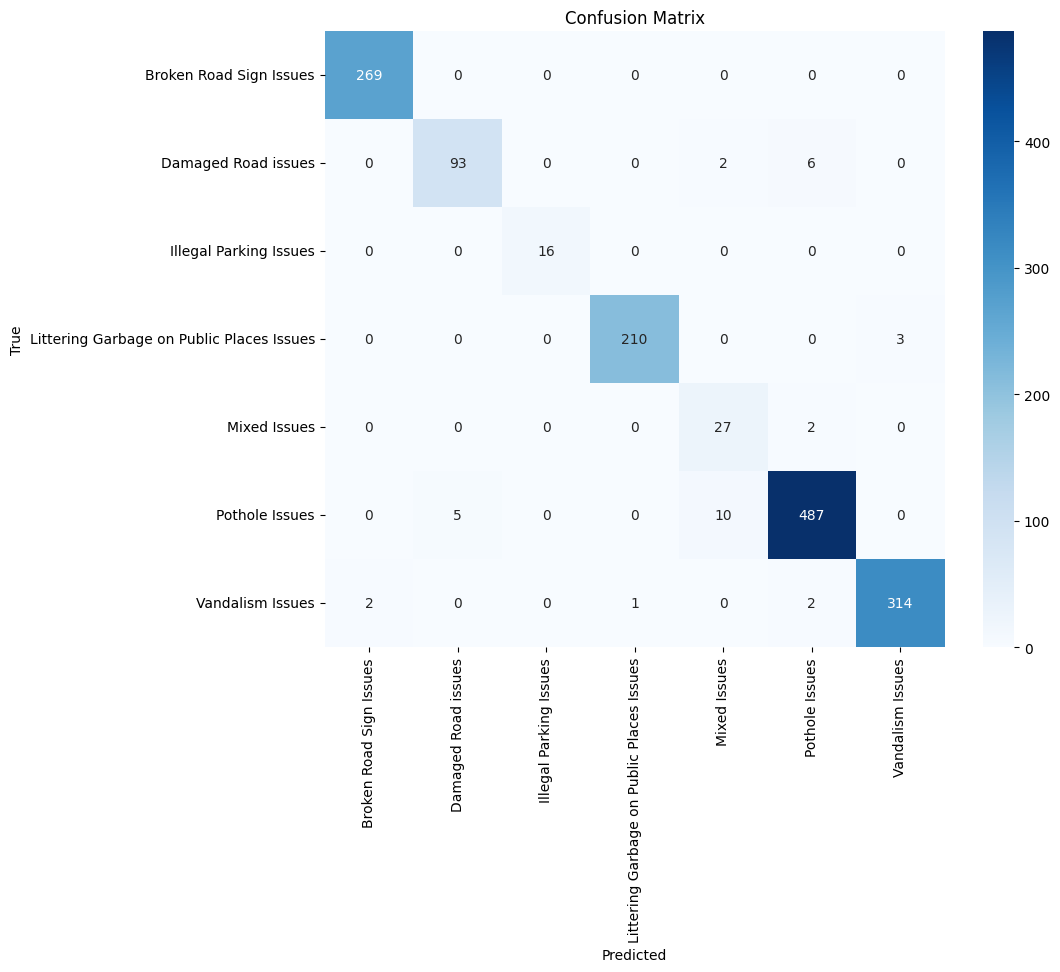

In [62]:
#plotting confusion matrix


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
# classification report

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

                                           precision    recall  f1-score   support

                  Broken Road Sign Issues       0.99      1.00      1.00       269
                      Damaged Road issues       0.95      0.92      0.93       101
                   Illegal Parking Issues       1.00      1.00      1.00        16
Littering Garbage on Public Places Issues       1.00      0.99      0.99       213
                             Mixed Issues       0.69      0.93      0.79        29
                           Pothole Issues       0.98      0.97      0.97       502
                         Vandalism Issues       0.99      0.98      0.99       319

                                 accuracy                           0.98      1449
                                macro avg       0.94      0.97      0.95      1449
                             weighted avg       0.98      0.98      0.98      1449



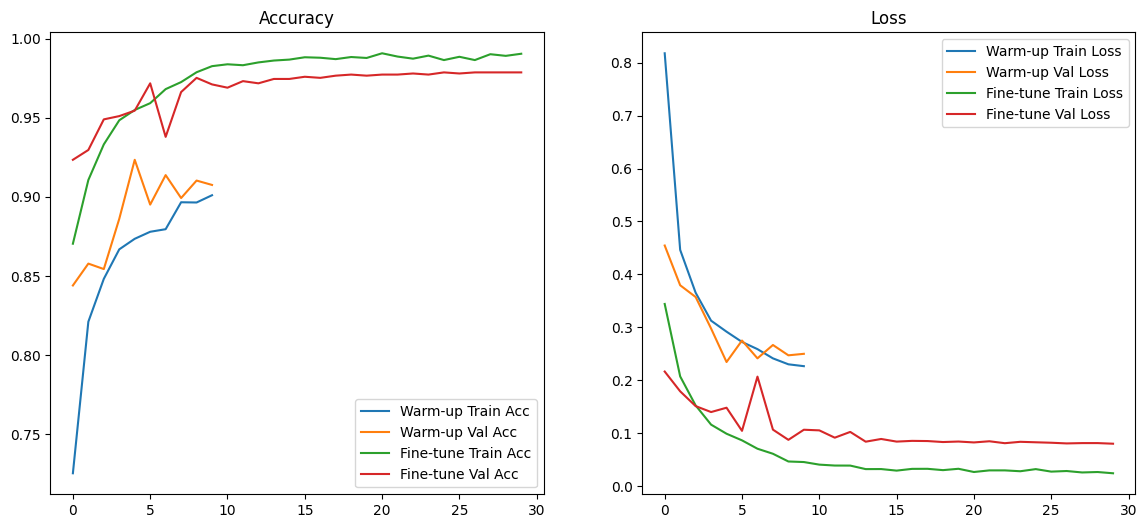

In [64]:
# training loss, validaton loss and training accuracy and validation accuracy plots


def plot_history(history_list, labels):
    plt.figure(figsize=(14, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    for history, label in zip(history_list, labels):
        plt.plot(history.history["accuracy"], label=f"{label} Train Acc")
        plt.plot(history.history["val_accuracy"], label=f"{label} Val Acc")
    plt.title("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    for history, label in zip(history_list, labels):
        plt.plot(history.history["loss"], label=f"{label} Train Loss")
        plt.plot(history.history["val_loss"], label=f"{label} Val Loss")
    plt.title("Loss")
    plt.legend()

    plt.show()

# Example usage:
plot_history([history1, history2], ["Warm-up", "Fine-tune"])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


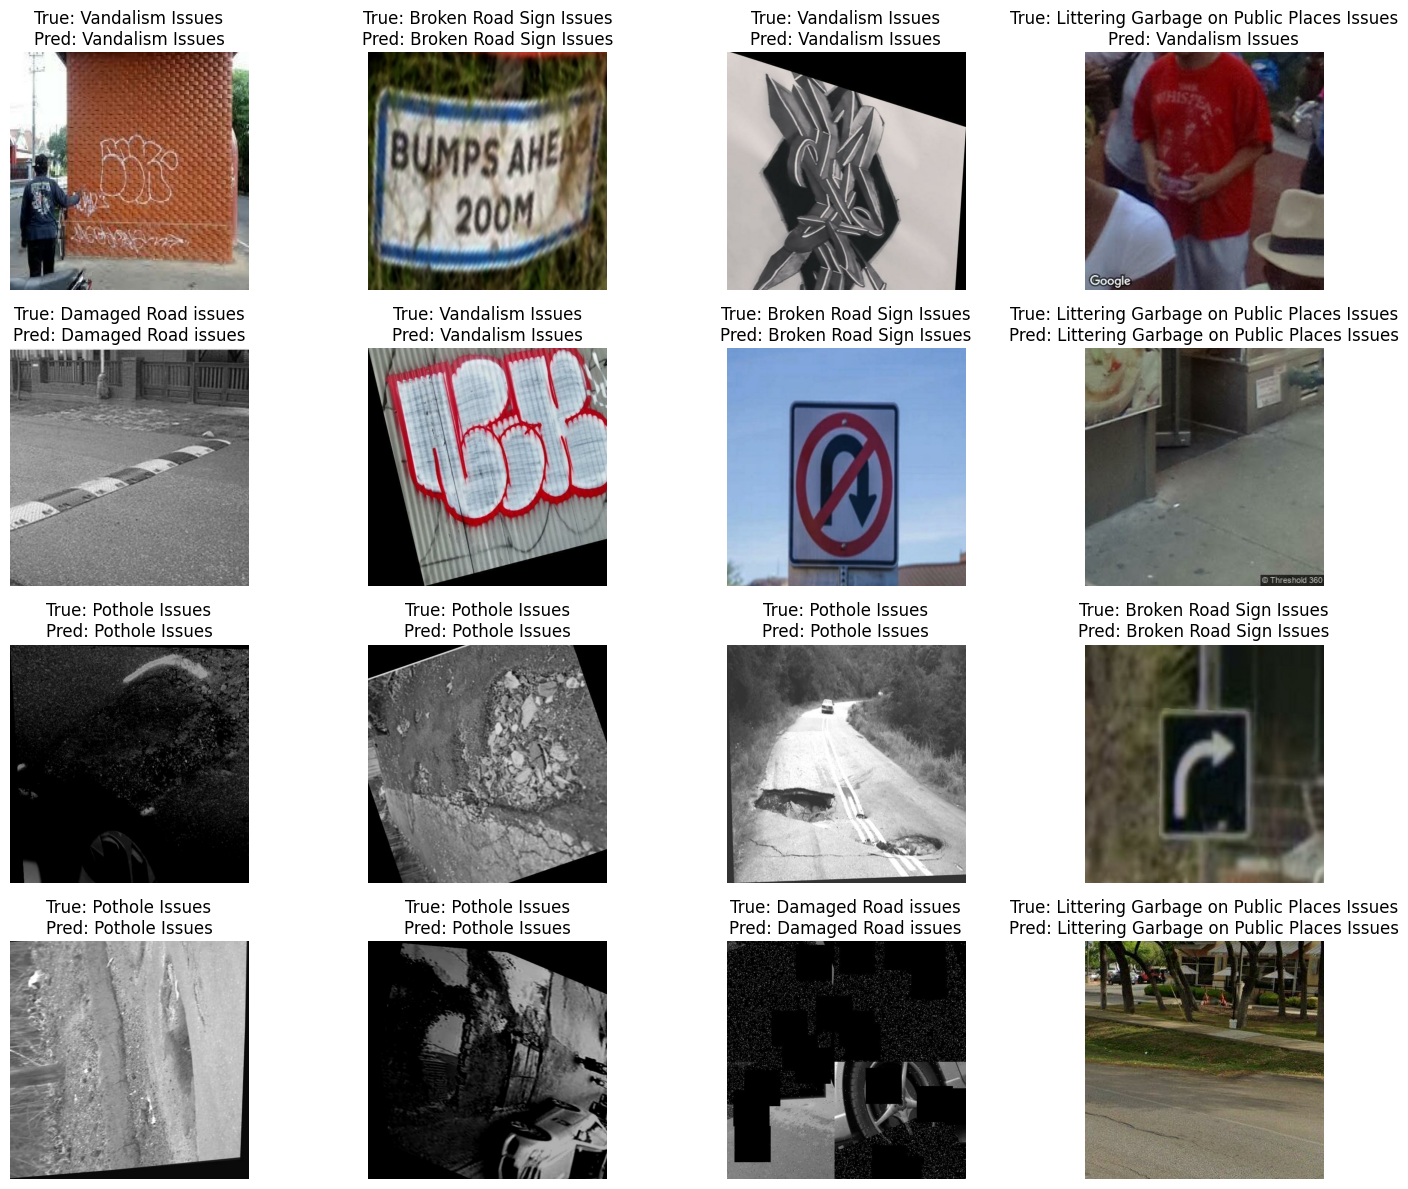

In [66]:
# sample predictions 

plt.figure(figsize=(15, 12))
sample_paths = test_df["path"].values[:16]
sample_labels = test_df["label_idx"].values[:16]

for i, (img_path, true_lbl) in enumerate(zip(sample_paths, sample_labels)):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img_resized = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img_input = tf.cast(img_resized, tf.float32)

    pred = model.predict(img_input[None, ...])[0]
    pred_class = np.argmax(pred)

    plt.subplot(4, 4, i+1)
    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"True: {class_names[true_lbl]}\nPred: {class_names[pred_class]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


Misclassified samples: 33


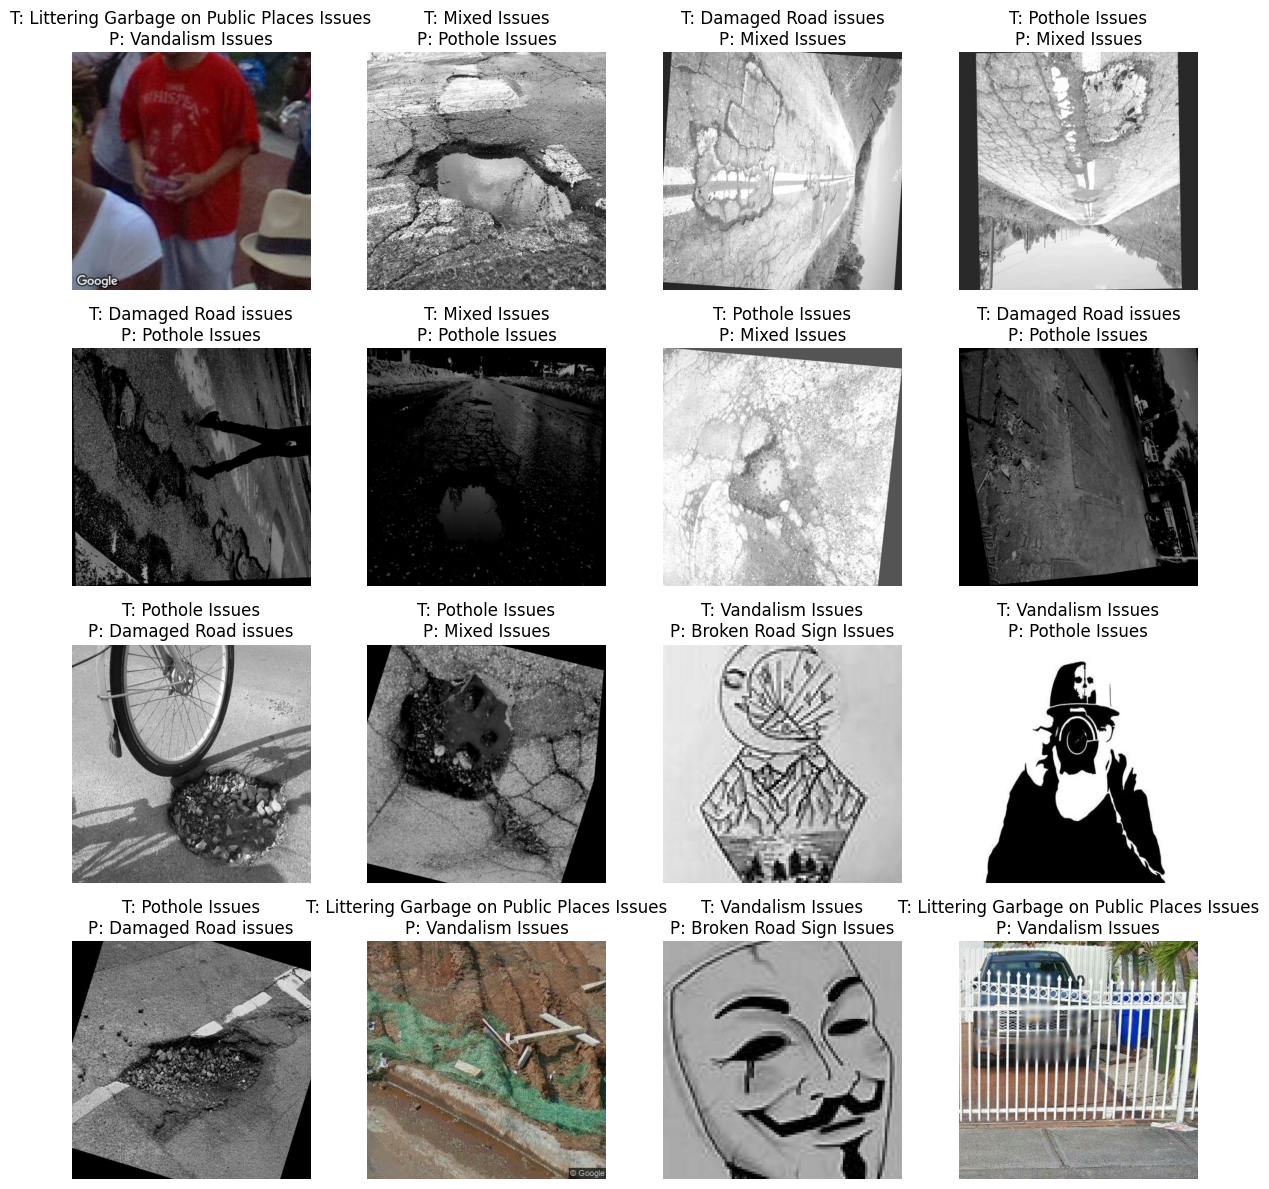

In [67]:
#misclassified images


mis_idx = np.where(y_true != y_pred)[0]
print("Misclassified samples:", len(mis_idx))

plt.figure(figsize=(12, 12))

for i, idx in enumerate(mis_idx[:16]):
    img_path = test_df.iloc[idx]["path"]
    true_lbl = y_true[idx]
    pred_lbl = y_pred[idx]

    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    
    plt.subplot(4, 4, i+1)
    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"T: {class_names[true_lbl]}\nP: {class_names[pred_lbl]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
MODEL_PATH = REPO_ROOT / "models" / "efficientnet_best_model.keras"
model.save(MODEL_PATH)
print(f"Model saved as {MODEL_PATH}")

Model saved!


In [ ]:
import tensorflow as tf

MODEL_PATH = REPO_ROOT / "models" / "efficientnet_best_model.keras"
model = tf.keras.models.load_model(MODEL_PATH)
print("OUTPUT SHAPE:", model.output_shape)

OUTPUT SHAPE: (None, 7)
